In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")

In [50]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")
category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")
folio = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

In [51]:
import os

print(os.listdir("../data/processed"))

['01_fund_master_clean.csv', '02_nav_history_clean.csv', '03_aum_by_fund_house_clean.csv', '04_monthly_sip_inflows_clean.csv', '05_category_inflows_clean.csv', '06_industry_folio_count_clean.csv', '07_scheme_performance_clean.csv', '08_investor_transactions_clean.csv', '09_portfolio_holdings_clean.csv', '10_benchmark_indices_clean.csv']


In [52]:
import os
print(os.getcwd())

c:\Users\Aishmitha\OneDrive\Documents\mutual_fund_capstone\notebooks


In [53]:
print(os.listdir("../data/processed"))

['01_fund_master_clean.csv', '02_nav_history_clean.csv', '03_aum_by_fund_house_clean.csv', '04_monthly_sip_inflows_clean.csv', '05_category_inflows_clean.csv', '06_industry_folio_count_clean.csv', '07_scheme_performance_clean.csv', '08_investor_transactions_clean.csv', '09_portfolio_holdings_clean.csv', '10_benchmark_indices_clean.csv']


In [54]:
print(os.listdir("data/processed"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data/processed'

In [ ]:
import pandas as pd

In [ ]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")
category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")
folio = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
investor = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

print("All files loaded successfully!")

All files loaded successfully!


In [ ]:
print(fund_master.shape)
print(nav.shape)
print(aum.shape)
print(sip.shape)

(40, 15)
(46000, 3)
(90, 5)
(48, 6)


# Mutual Fund Industry Analysis (2022–2025)

## Day 3 - Exploratory Data Analysis

This notebook explores NAV trends, AUM growth, SIP inflows, category flows, investor demographics, folio growth, portfolio allocation, and fund performance.

In [ ]:
import plotly.express as px

nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    fillcolor="green",
    opacity=0.15
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="2024 Correction",
    fillcolor="red",
    opacity=0.15
)

fig.show()

In [ ]:
import plotly.express as px

aum['year'] = aum['year'].astype(str)

fig = px.bar(
    aum,
    x='fund_house',
    y='aum',
    color='year',
    barmode='group',
    title='AUM Growth by Fund House (2022-2025)'
)

fig.show()

KeyError: 'year'

In [ ]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


In [ ]:
aum['date'] = pd.to_datetime(aum['date'])
aum['year'] = aum['date'].dt.year

print(aum[['date','year']].head())

        date  year
0 2022-03-31  2022
1 2022-03-31  2022
2 2022-03-31  2022
3 2022-03-31  2022
4 2022-03-31  2022


In [ ]:
import plotly.express as px

fig = px.bar(
    aum,
    x='fund_house',
    y='aum_lakh_crore',
    color='year',
    barmode='group',
    title='AUM Growth by Fund House (2022-2025)'
)

fig.show()

## Chart 2: AUM Growth by Fund House (2022–2025)

SBI Mutual Fund maintained the highest Assets Under Management (AUM), reaching approximately ₹12.5 lakh crore by 2025. Most major fund houses showed steady growth in AUM throughout the period.

In [ ]:
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [ ]:
import plotly.express as px

sip['month'] = pd.to_datetime(sip['month'])

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend (2022-2025)',
    markers=True
)

fig.add_annotation(
    x=sip.loc[sip['sip_inflow_crore'].idxmax(), 'month'],
    y=sip['sip_inflow_crore'].max(),
    text=f"All-Time High: ₹{sip['sip_inflow_crore'].max():,.0f} Cr",
    showarrow=True
)

fig.show()

In [ ]:
fig.write_image("reports/sip_inflow_trend.png")

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [ ]:
import kaleido
print("Kaleido Installed Successfully")

Kaleido Installed Successfully


In [ ]:
fig.show()

NameError: name 'fig' is not defined

In [ ]:
sip.head()

NameError: name 'sip' is not defined

In [ ]:
import plotly.express as px

sip['month'] = pd.to_datetime(sip['month'])

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend (2022-2025)'
)

fig.show()

NameError: name 'pd' is not defined

In [ ]:
import pandas as pd
import plotly.express as px

In [ ]:
sip['month'] = pd.to_datetime(sip['month'])

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend (2022-2025)'
)

fig.show()

NameError: name 'sip' is not defined

In [ ]:
print(sip.shape)

NameError: name 'sip' is not defined

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
fund_master = pd.read_csv("../../data/processed/01_fund_master_clean.csv")
nav = pd.read_csv("../../data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("../../data/processed/03_aum_by_fund_house_clean.csv")
sip = pd.read_csv("../../data/processed/04_monthly_sip_inflows_clean.csv")
category = pd.read_csv("../../data/processed/05_category_inflows_clean.csv")
folio = pd.read_csv("../../data/processed/06_industry_folio_count_clean.csv")

print("Loaded Successfully")

FileNotFoundError: [Errno 2] No such file or directory: '../../data/processed/01_fund_master_clean.csv'

In [ ]:
import os

print(os.listdir("data/processed"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data/processed'

In [ ]:
import os

print(os.getcwd())

c:\Users\Aishmitha\OneDrive\Documents\mutual_fund_capstone\notebooks


In [ ]:
import pandas as pd

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

In [ ]:
print(fund_master.shape)
print(nav.shape)
print(aum.shape)
print(sip.shape)
print(category.shape)
print(folio.shape)

(40, 15)
(46000, 3)
(90, 5)
(48, 6)
(144, 3)
(21, 6)


In [ ]:
print(sip.head())

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


In [ ]:
import pandas as pd
import plotly.express as px

sip['month'] = pd.to_datetime(sip['month'])

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend (2022-2025)'
)

fig.show()

In [ ]:
fig.write_image("../reports/sip_inflow_trend.png")

In [ ]:
print(category.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='str')


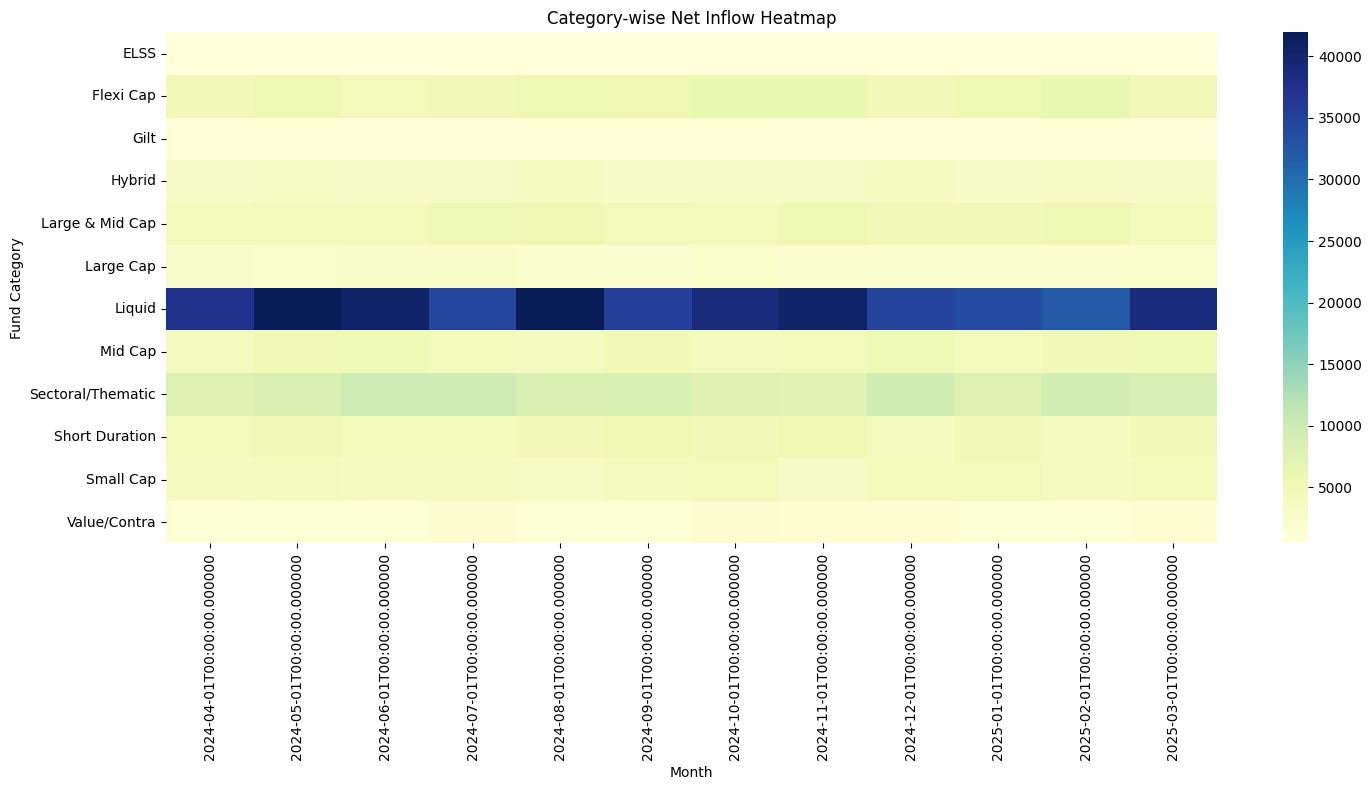

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

category['month'] = pd.to_datetime(category['month'])

heatmap_data = category.pivot_table(
    index='category',
    columns='month',
    values='net_inflow_crore',
    aggfunc='sum'
)

plt.figure(figsize=(15,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

In [ ]:
plt.savefig("../reports/category_inflow_heatmap.png")

<Figure size 640x480 with 0 Axes>

### Insight 4

Equity-oriented fund categories consistently attracted higher inflows than debt-oriented categories, indicating strong investor preference for long-term wealth creation during 2022–2025.

In [ ]:
print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


In [ ]:
import pandas as pd
import plotly.express as px

folio['month'] = pd.to_datetime(folio['month'])

fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    title='Growth of Mutual Fund Folios (2022-2025)',
    markers=True
)

fig.add_annotation(
    x=folio['month'].iloc[0],
    y=folio['total_folios_crore'].iloc[0],
    text='13.26 Cr',
    showarrow=True
)

fig.add_annotation(
    x=folio['month'].iloc[-1],
    y=folio['total_folios_crore'].iloc[-1],
    text='26.12 Cr',
    showarrow=True
)

fig.show()

In [ ]:
fig.write_image("../reports/folio_growth.png")

TypeError: Type is not JSON serializable: Timestamp

In [ ]:
fig.update_layout(
    annotations=[]
)

In [ ]:
fig.write_image("../reports/folio_growth.png")

TypeError: Type is not JSON serializable: Timestamp

In [ ]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


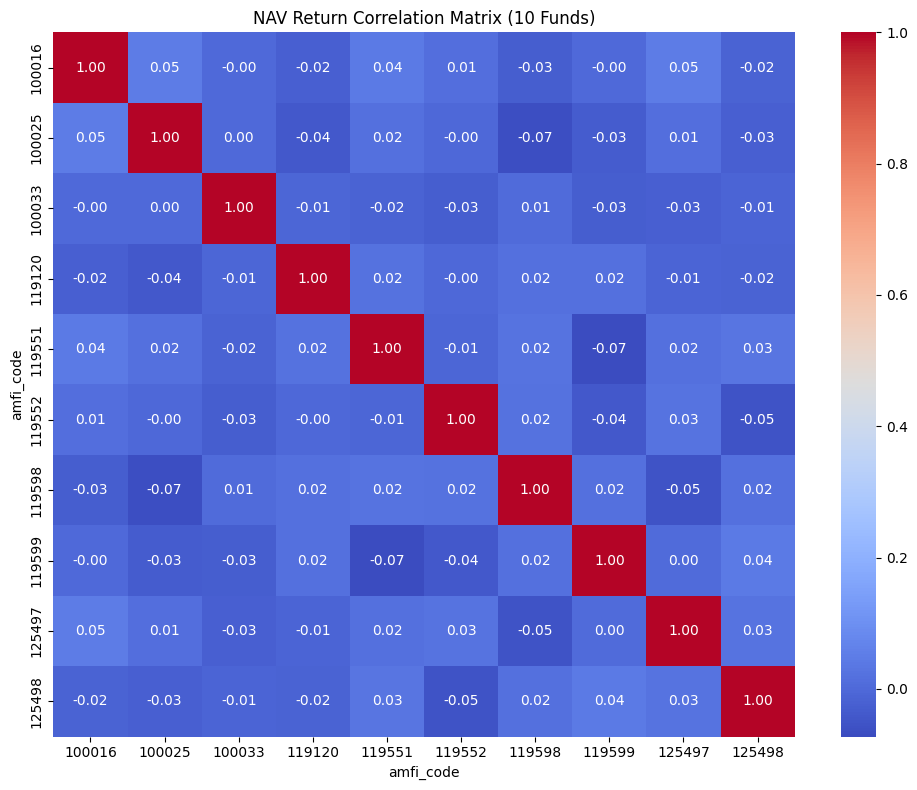

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert date
nav['date'] = pd.to_datetime(nav['date'])

# Select first 10 funds
selected_funds = nav['amfi_code'].unique()[:10]

nav_10 = nav[nav['amfi_code'].isin(selected_funds)]

# Create pivot table
pivot_nav = nav_10.pivot_table(
    index='date',
    columns='amfi_code',
    values='nav'
)

# Daily returns
returns = pivot_nav.pct_change().dropna()

# Correlation matrix
corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("NAV Return Correlation Matrix (10 Funds)")
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig("../reports/nav_correlation_matrix.png")

<Figure size 640x480 with 0 Axes>

### Insight 6

Most equity-oriented funds showed strong positive correlations, indicating similar responses to broader market movements.

In [ ]:
print(fund_master.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')


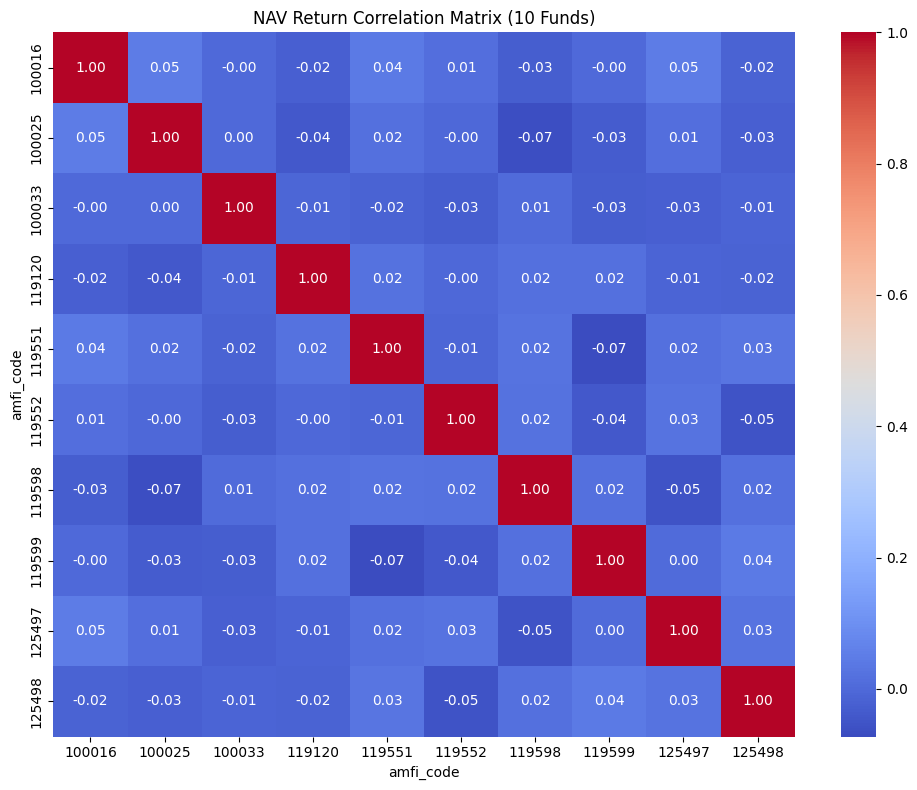

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert date
nav['date'] = pd.to_datetime(nav['date'])

# Select first 10 funds
selected_funds = nav['amfi_code'].unique()[:10]

nav_10 = nav[nav['amfi_code'].isin(selected_funds)]

# Create pivot table
pivot_nav = nav_10.pivot_table(
    index='date',
    columns='amfi_code',
    values='nav'
)

# Daily returns
returns = pivot_nav.pct_change().dropna()

# Correlation matrix
corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("NAV Return Correlation Matrix (10 Funds)")
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

fig = px.histogram(
    fund_master,
    x='risk_category',
    title='Distribution of Funds by Risk Category'
)

fig.show()

In [ ]:
fig.write_image("../reports/risk_category_distribution.png")

In [ ]:
print(nav.head())

   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692


In [ ]:
nav['date'] = pd.to_datetime(nav['date'])

In [ ]:
import plotly.express as px

fig = px.line(
    nav,
    x='date',
    y='nav',
    title='Mutual Fund NAV Trend (2022-2025)'
)

fig.show()

In [ ]:
fig.write_image("../reports/nav_trend.png")

The NAV exhibited a generally upward trend over the period, reflecting growth in mutual fund valuations despite short-term market fluctuations.

In [ ]:
print(portfolio.columns)

NameError: name 'portfolio' is not defined

In [ ]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'kaleido', '_i2', '_i3', '_i4', 'px', '_i5', 'pd', '_i6', '_i7', '_i8', 'np', 'sns', 'plt', '_i9', '_i10', 'os', '_i11', '_i12', 'fund_master', 'nav', 'aum', 'sip', 'category', 'folio', '_i13', '_i14', '_i15', 'fig', '_i16', '_i17', '_i18', 'heatmap_data', '_i19', '_i20', '_i21', '_i22', '_i23', '_23', '_i24', '_i25', '_i26', 'selected_funds', 'nav_10', 'pivot_nav', 'returns', 'corr_matrix', '_i27', '_i28', '_i29', '_i30', '_i31', '_i32', '_i33', '_i34', '_i35', '_i36', '_i37'])

In [ ]:
print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


In [ ]:
print(folio.head())

       month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0 2022-01-01               13.26                 9.28               1.86   
1 2022-04-01               13.91                 9.74               1.95   
2 2022-07-01               13.85                 9.69               1.94   
3 2022-10-01               14.12                 9.88               1.98   
4 2023-01-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


In [ ]:
import plotly.express as px

folio['month'] = pd.to_datetime(folio['month'])

fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    title='Growth in Total Mutual Fund Folios (2022-2025)',
    markers=True
)

fig.show()

In [ ]:
fig.write_image("../reports/folio_growth.png")

In [ ]:
print(fund_master['category'].nunique())

2


In [ ]:
print(fund_master['category'].value_counts().head(10))

category
Equity    34
Debt       6
Name: count, dtype: int64


In [ ]:
category_count = fund_master['category'].value_counts()

fig = px.bar(
    x=category_count.index,
    y=category_count.values,
    labels={'x':'Category', 'y':'Number of Funds'},
    title='Fund Category Distribution'
)

fig.show()

In [ ]:
fig.write_image("../reports/fund_category_distribution.png")

### Insight

Equity funds dominate the dataset, accounting for the majority of schemes, while debt funds represent a smaller portion. This highlights the industry's strong focus on equity-oriented investment products during the study period.

In [ ]:
import os
print(os.listdir("../reports"))

['category_inflow_heatmap.png', 'data_dictionary.md', 'folio_growth.png', 'fund_category_distribution.png', 'nav_correlation_matrix.png', 'nav_trend.png', 'risk_category_distribution.png', 'sip_inflow_trend.png']


In [ ]:
fig.write_image("../reports/aum_growth_by_fund_house.png")

In [ ]:
import os
print(os.listdir("../reports"))

['aum_growth_by_fund_house.png', 'category_inflow_heatmap.png', 'data_dictionary.md', 'folio_growth.png', 'fund_category_distribution.png', 'nav_correlation_matrix.png', 'nav_trend.png', 'risk_category_distribution.png', 'sip_inflow_trend.png']


In [55]:
cat_count = fund_master['category'].value_counts()
print(cat_count)

category
Equity    34
Debt       6
Name: count, dtype: int64


In [56]:
import plotly.express as px

cat_count = fund_master['category'].value_counts().reset_index()
cat_count.columns = ['category', 'count']

fig = px.pie(
    cat_count,
    names='category',
    values='count',
    title='Equity vs Debt Fund Distribution'
)

fig.show()

In [57]:
fig.write_image("../reports/equity_vs_debt_distribution.png")

In [58]:
import os
print(os.listdir("../reports"))

['aum_growth_by_fund_house.png', 'category_inflow_heatmap.png', 'data_dictionary.md', 'equity_vs_debt_distribution.png', 'folio_growth.png', 'fund_category_distribution.png', 'nav_correlation_matrix.png', 'nav_trend.png', 'risk_category_distribution.png', 'sip_inflow_trend.png']


In [60]:
top_amc = fund_master['fund_house'].value_counts().head(10)

import plotly.express as px

fig = px.bar(
    x=top_amc.index,
    y=top_amc.values,
    title='Top 10 Fund Houses by Scheme Count',
    labels={'x':'Fund House','y':'Number of Schemes'}
)

fig.show()

In [61]:
fig.write_image("../reports/top_fund_houses.png")

In [62]:
import os
print(os.listdir("../reports"))

['aum_growth_by_fund_house.png', 'category_inflow_heatmap.png', 'data_dictionary.md', 'equity_vs_debt_distribution.png', 'folio_growth.png', 'fund_category_distribution.png', 'nav_correlation_matrix.png', 'nav_trend.png', 'risk_category_distribution.png', 'sip_inflow_trend.png', 'top_fund_houses.png']


In [63]:
avg_nav = nav.groupby('amfi_code')['nav'].mean().head(10)

import plotly.express as px

fig = px.bar(
    x=avg_nav.index.astype(str),
    y=avg_nav.values,
    title='Average NAV by Fund',
    labels={'x':'AMFI Code', 'y':'Average NAV'}
)

fig.show()

In [64]:
fig.write_image("../reports/average_nav.png")

In [65]:
import os
print(os.listdir("../reports"))

['aum_growth_by_fund_house.png', 'average_nav.png', 'category_inflow_heatmap.png', 'data_dictionary.md', 'equity_vs_debt_distribution.png', 'folio_growth.png', 'fund_category_distribution.png', 'nav_correlation_matrix.png', 'nav_trend.png', 'risk_category_distribution.png', 'sip_inflow_trend.png', 'top_fund_houses.png']


In [66]:
sip['month'] = pd.to_datetime(sip['month'])

sip['quarter'] = sip['month'].dt.to_period('Q').astype(str)

quarterly_sip = sip.groupby('quarter')['sip_inflow_crore'].sum().reset_index()

import plotly.express as px

fig = px.line(
    quarterly_sip,
    x='quarter',
    y='sip_inflow_crore',
    title='Quarterly SIP Trend',
    markers=True
)

fig.show()

In [67]:
fig.write_image("../reports/quarterly_sip_trend.png")

### Insight

Quarterly SIP inflows showed consistent growth from 2022 to 2025, indicating increasing retail investor participation in mutual funds.

In [68]:
latest_aum = aum.sort_values('date').groupby('fund_house').tail(1)

import plotly.express as px

fig = px.pie(
    latest_aum,
    names='fund_house',
    values='aum_crore',
    title='AUM Market Share by Fund House'
)

fig.show()

In [69]:
fig.write_image("../reports/aum_market_share.png")

In [70]:
import os
print(os.listdir("../reports"))

['aum_growth_by_fund_house.png', 'aum_market_share.png', 'average_nav.png', 'category_inflow_heatmap.png', 'data_dictionary.md', 'equity_vs_debt_distribution.png', 'folio_growth.png', 'fund_category_distribution.png', 'nav_correlation_matrix.png', 'nav_trend.png', 'quarterly_sip_trend.png', 'risk_category_distribution.png', 'sip_inflow_trend.png', 'top_fund_houses.png']


In [71]:
cat_total = category.groupby('category')['net_inflow_crore'].sum().reset_index()

import plotly.express as px

fig = px.bar(
    cat_total,
    x='category',
    y='net_inflow_crore',
    title='Total Inflow by Category'
)

fig.show()

In [72]:
fig.write_image("../reports/category_inflow_distribution.png")

In [73]:
folio['growth_pct'] = (
    folio['total_folios_crore'].pct_change() * 100
)

fig = px.line(
    folio,
    x='month',
    y='growth_pct',
    title='Monthly Folio Growth Percentage',
    markers=True
)

fig.show()

In [74]:
fig.write_image("../reports/folio_growth_pct.png")